# Ejercicio Posgrado M4 - Xavier Pons Palomares

In [59]:
#Importamos librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Fijar la "seed" para que todos tengamos los mismos resultados
np.random.seed(1234)
seed = 0

#Evitar warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [60]:
df_train = pd.read_csv('Data/train_FD001.txt', sep= ' ', header=None)
df_test = pd.read_csv('Data/test_FD001.txt', sep= ' ', header=None)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


Ahora procederemos a eliminar las columnas 26 y 27 ya que tienen valores que no interesan


In [61]:
df_train.drop(df_train.columns[[26, 27]], axis=1, inplace=True)
df_test.drop(df_test.columns[[26, 27]], axis=1, inplace=True)
df_train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Procedemos a cambiar el nombre de las columnas

In [62]:
columnas_1 = ['Unidad', 'Ciclo',]
columnas_2 = ['AjOP_' + str(i) for i in range(1,4)]
columnas_3 = ['Sensor_' + str(i) for i in range(1,22)]
columnas_nombres = columnas_1 + columnas_2 + columnas_3
print(columnas_nombres)

['Unidad', 'Ciclo', 'AjOP_1', 'AjOP_2', 'AjOP_3', 'Sensor_1', 'Sensor_2', 'Sensor_3', 'Sensor_4', 'Sensor_5', 'Sensor_6', 'Sensor_7', 'Sensor_8', 'Sensor_9', 'Sensor_10', 'Sensor_11', 'Sensor_12', 'Sensor_13', 'Sensor_14', 'Sensor_15', 'Sensor_16', 'Sensor_17', 'Sensor_18', 'Sensor_19', 'Sensor_20', 'Sensor_21']


In [63]:
df_train.columns = columnas_nombres
df_test.columns = columnas_nombres
df_train.head()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [64]:
max_ciclo = df_train.groupby('Unidad')['Ciclo'].max().reset_index()
max_ciclo.columns = ['Unidad', 'MaxCiclo']
max_ciclo.head()

,Unidad,MaxCiclo
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269


In [65]:
train_merged = df_train.merge(max_ciclo, left_on = 'Unidad', right_on = 'Unidad', how = 'inner')
train_merged.head()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,MaxCiclo
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,192
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,192
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,192
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,192


In [66]:
train_merged['Rul'] = train_merged['MaxCiclo']-train_merged['Ciclo']
train_merged.drop('MaxCiclo', axis=1, inplace=True)
train_merged.head()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [67]:
train_merged.tail()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Rul
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522,0


Ejercicio clasificación: Procederemos a clasificar en base al RUL de forma binaria. Primero lo clasificaremos en dos estados y luego lo transformaremos a binario

In [68]:
train_merged['Rul'] = np.where(train_merged['Rul'] <= 20,'Status1','Status2')
train_merged.head()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Rul
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,Status2
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,Status2
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,Status2
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,Status2
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,Status2


In [69]:
train_merged.tail()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Rul
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,Status1
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,Status1
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,Status1
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,Status1
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522,Status1


In [70]:
from sklearn.preprocessing import LabelEncoder

lab_encoder = LabelEncoder() 
lab_encoder.fit(train_merged['Rul'])  
print(lab_encoder.classes_)  # Muestra las clases diferentes que hay

train_merged['Rul'] = lab_encoder.transform(train_merged['Rul'])
print(train_merged)

['Status1' 'Status2']
       Unidad  Ciclo  AjOP_1  AjOP_2  AjOP_3  Sensor_1  Sensor_2  Sensor_3  \
0           1      1 -0.0007 -0.0004   100.0    518.67    641.82   1589.70   
1           1      2  0.0019 -0.0003   100.0    518.67    642.15   1591.82   
2           1      3 -0.0043  0.0003   100.0    518.67    642.35   1587.99   
3           1      4  0.0007  0.0000   100.0    518.67    642.35   1582.79   
4           1      5 -0.0019 -0.0002   100.0    518.67    642.37   1582.85   
...       ...    ...     ...     ...     ...       ...       ...       ...   
20626     100    196 -0.0004 -0.0003   100.0    518.67    643.49   1597.98   
20627     100    197 -0.0016 -0.0005   100.0    518.67    643.54   1604.50   
20628     100    198  0.0004  0.0000   100.0    518.67    643.42   1602.46   
20629     100    199 -0.0011  0.0003   100.0    518.67    643.23   1605.26   
20630     100    200 -0.0032 -0.0005   100.0    518.67    643.85   1600.38   

       Sensor_4  Sensor_5  ...  Sensor_13

## Fase 1. Comprensión de los datos

En este primera fase veremos que datos tenemos, en general nos interesan los atributos y clases que tenemos así como  una visión estadística y visualizar la distribución de los datos 

In [71]:
train_merged.shape

(20631, 27)

In [72]:
train_merged.describe()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21,Rul
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,0.898211
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251,0.302377
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,0.000000
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,1.000000
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,1.000000
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,1.000000
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,1.000000


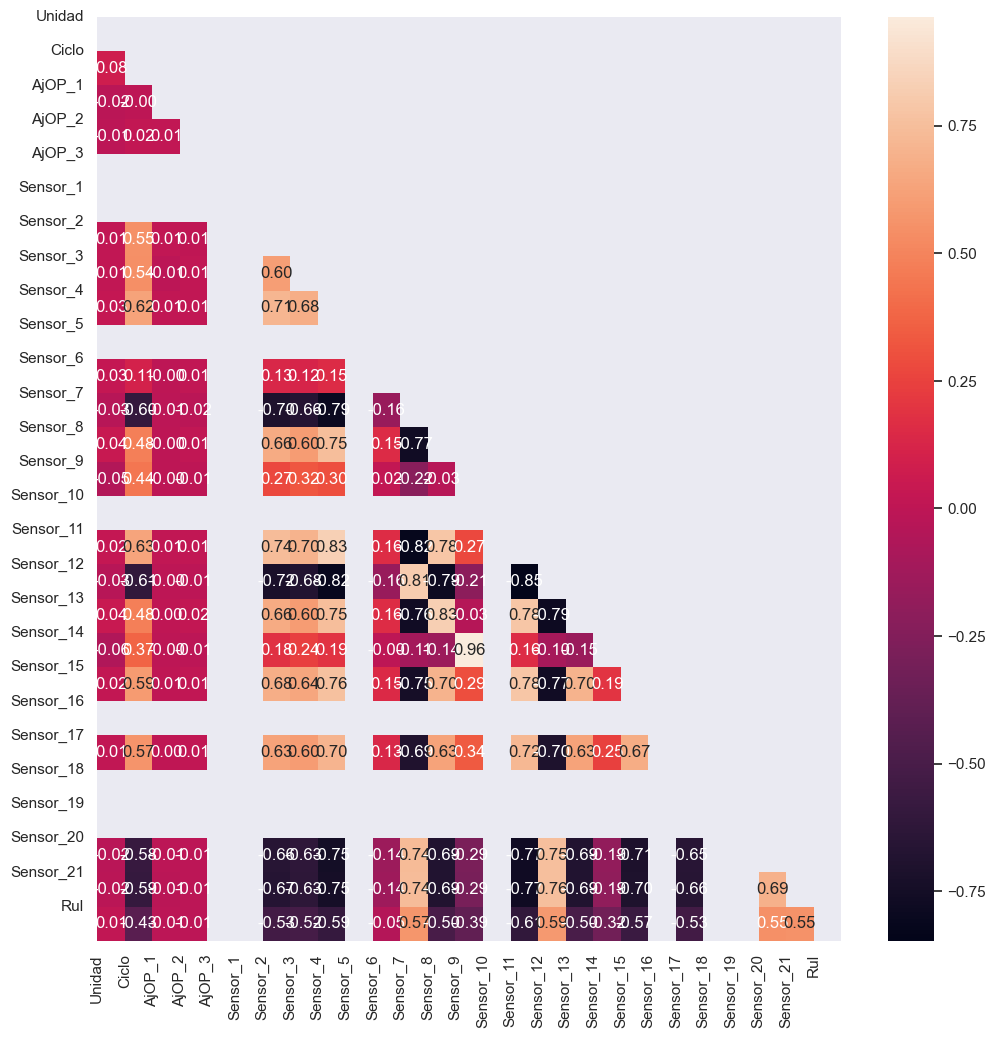

In [73]:
# Otra librería de visualización de datos
import seaborn as sns

# Cálculo de coeficientes de correlación
corr_matrix = train_merged.corr(method='pearson') 


# Quitar valores repetidos
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

  
f, ax = plt.subplots(figsize=(12, 12))
#Generar Heat Map,
sns.heatmap(corr_matrix, annot=True, fmt=".2f" , mask=mask,)
    # xticks
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns);
    # yticks
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
    # plot
plt.show()

La matriz de correlación nos indica atributos que son irrelevantes para el campo que estamos tratando y que podríamos eliminar posteriormente para eliminar ruido

## Fase 2. Preparación de datos

In [74]:
train_merged_features = train_merged.iloc[:, :26]

In [75]:
train_merged_features.head()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [76]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_merged_features_sc = train_merged_features.copy()
train_merged_features_sc = pd.DataFrame(scaler.fit_transform(train_merged_features))
train_merged_features_sc.columns = train_merged_features.columns
train_merged_features_sc.head()



,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,0.0,0.00000,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662
1,0.0,0.00277,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014
2,0.0,0.00554,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375
3,0.0,0.00831,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386
4,0.0,0.01108,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502


## Fase 3. División de datos
Ahora realizaremos la división de los datos de la siguiente forma:
- De entrenamiento 70%
- Datos de Validación 15%
- Datos de Prueba 15%.

Primero, divido los datos en:

    Features/características/atributos/variables de entrada: X
    Target/etiquedas: Y


In [77]:
# Atributos X (features); etiquetas y (target)
X = train_merged_features_sc.copy()
X.head()

,Unidad,Ciclo,AjOP_1,AjOP_2,AjOP_3,Sensor_1,Sensor_2,Sensor_3,Sensor_4,Sensor_5,...,Sensor_12,Sensor_13,Sensor_14,Sensor_15,Sensor_16,Sensor_17,Sensor_18,Sensor_19,Sensor_20,Sensor_21
0,0.0,0.00000,0.459770,0.166667,0.0,0.0,0.183735,0.406802,0.309757,0.0,...,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662
1,0.0,0.00277,0.609195,0.250000,0.0,0.0,0.283133,0.453019,0.352633,0.0,...,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014
2,0.0,0.00554,0.252874,0.750000,0.0,0.0,0.343373,0.369523,0.370527,0.0,...,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375
3,0.0,0.00831,0.540230,0.500000,0.0,0.0,0.343373,0.256159,0.331195,0.0,...,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386
4,0.0,0.01108,0.390805,0.333333,0.0,0.0,0.349398,0.257467,0.404625,0.0,...,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502


In [78]:
X = X.to_numpy()

In [79]:
Y = train_merged[["Rul"]]
Y = Y.to_numpy()

In [80]:
train_merged.isna().sum()

Unidad       0
Ciclo        0
AjOP_1       0
AjOP_2       0
AjOP_3       0
Sensor_1     0
Sensor_2     0
Sensor_3     0
Sensor_4     0
Sensor_5     0
Sensor_6     0
Sensor_7     0
Sensor_8     0
Sensor_9     0
Sensor_10    0
Sensor_11    0
Sensor_12    0
Sensor_13    0
Sensor_14    0
Sensor_15    0
Sensor_16    0
Sensor_17    0
Sensor_18    0
Sensor_19    0
Sensor_20    0
Sensor_21    0
Rul          0
dtype: int64

In [81]:
from sklearn.model_selection import train_test_split

test_size = 0.15  # porcentaje de los datos de entrada que utilizaré para validar el modelo

# Divido los datos en datos de entreno, validación y prueba

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, shuffle=False)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=test_size, shuffle=False)


In [82]:
len(X_train)

14905

## Fase 4. Construcción y evaluación del modelo
Ahora procederemos a la creación del modelo teniendo en cuenta las diferentes opciones que serían:
- Regresión Lineal
- Random Forest
- K-Neighbors
- Red Neuronal

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb  

num_folds = 5
error_metrics = {'balanced_accuracy'}
models = { ('LR', LogisticRegression()), 
          ('KNN', KNeighborsClassifier()),
           ('RF', RandomForestClassifier())
         }

results = [] # guarda los resultados de las métricas de evaluación
names = []  # Nombre de cada algoritmo
msg = []  # imprime el resumen del método de cross-validation

Ahora procederemos a entrenar el modelo con validación cruzada y procederemos a comparar entre los diferentes algoritmos para poder determinar la precisión así como el grado de la misma y decidir cual es el mejor para nuestro caso

Métrica de evaluación:  balanced_accuracy
Modelo  KNN
Modelo  LR
Modelo  RF
[('KNN', 0.9042461238423997, 0.02356380733058549), ('LR', 0.9198489403539789, 0.024499729952976782), ('RF', 0.92462986722871, 0.0176339126955343)]


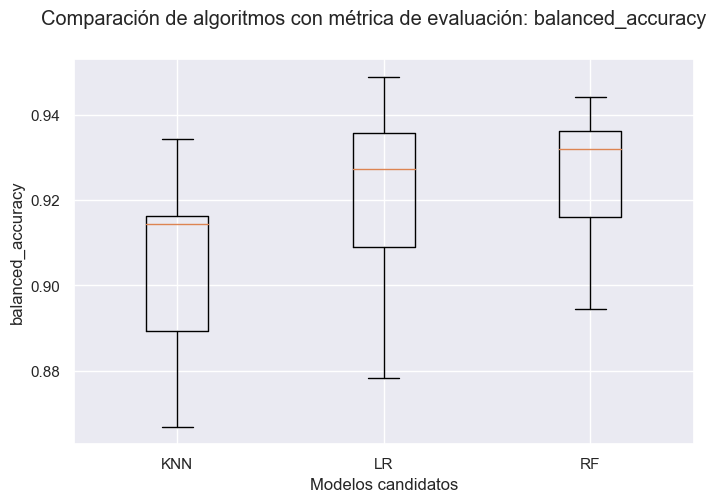

In [84]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
import seaborn as sns
import numpy as np


for scoring in error_metrics:
    print('Métrica de evaluación: ', scoring)
    for name, model in models:
        print('Modelo ', name)
        cross_validation = TimeSeriesSplit(n_splits=num_folds)
        cv_results = cross_val_score(model, X_train, np.ravel(y_train), cv=cross_validation, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        resume = (name, cv_results.mean(), cv_results.std())
        msg.append(resume)
    print(msg)

    
    sns.set(rc={'figure.figsize':(8,5)})
    fig = plt.figure()
    fig.suptitle('Comparación de algoritmos con métrica de evaluación: %s' %scoring)
    ax = fig.add_subplot(111)
    ax.set_xlabel('Modelos candidatos')
    ax.set_ylabel('%s' %scoring)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

    results = []

Vemos que el mejor es el RF con un 92,4%

## Fase 5. Ajustar hiperparámetros
Ahora procederemos a la realización del hiperajuste de los parámetros para el Random Forest

- Métrica para optimizar: balanced_accuracy
- Definir los rangos de los parámetros de búsqueda: params
- Entrenar con los datos de validación: X_val
- Escalar los valores de validación (aunque en RF no sería necesario)


In [85]:
from sklearn.model_selection import TimeSeriesSplit

# RF
modelo = RandomForestClassifier()
hyperparams = {
     'n_estimators': [100, 500, 800], #default=100
     'min_samples_split': [2, 4], #default=2
     'bootstrap': [True, False],  #default=True
 }

scoring='balanced_accuracy'
cross_validation = TimeSeriesSplit(n_splits=10)
my_cv = cross_validation.split(X_val, y_val)
gsearch = GridSearchCV(estimator=modelo, param_grid=hyperparams, scoring=scoring, cv=my_cv, verbose=2) 
gsearch.fit(X_val, np.ravel(y_val))

print("Mejor resultado: %f utilizando los siguientes hiperparámetros %s" % (gsearch.best_score_, gsearch.best_params_))
means = gsearch.cv_results_['mean_test_score']
stds = gsearch.cv_results_['std_test_score']
params = gsearch.cv_results_['params']
# for mean, stdev, param in zip(means, stds, params):
#     print("%f (%f) with: %r" % (mean, stdev, param))

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END bootstrap=True, min_samples_split=2, n_estimators=500; total time=   0.5s
[CV] END bootstrap=True,

[CV] END bootstrap=False, min_samples_split=4, n_estimators=100; total time=   0.3s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=100; total time=   0.3s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   0.4s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   0.5s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   0.6s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   0.8s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   0.9s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   1.2s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   1.4s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   1.5s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=   1.7s
[CV] END bootstrap=False, min_samples_split=4, n_estimators=500; total time=

Con los hiperparámetros hemos logrado mejorar nuestro modelo en un 0,5% logrando el 92,9%

## Fase 6. Evaluación final del modelo
Para este último paso usaremos las métricas de evaluación:

- Matriz de confusión
- Coeficiente de Matthews (MCC)

Entrena el modelo con los hiperparámetros óptimos encontrados en el apartado anterior y realiza las predicciones.

In [86]:
# modelo_final = RandomForestClassifier(max_features='sqrt', min_samples_split=2,  n_estimators=500, class_weight={0:1,1:5})
modelo_final =RandomForestClassifier(bootstrap=False, min_samples_split=2, n_estimators= 100)
modelo_final.fit(X_train, np.ravel(y_train))  # Se entrena al modelo RF con los hiperparámetros seleccionados.


# Realizo las predicciones
y_predict = modelo_final.predict(X_test)  # Se calculan las predicciones

In [87]:
y_predict

array([1, 1, 1, ..., 0, 0, 0])

In [88]:
y_test

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]])

### Métricas de Evaluación

Primero la matriz de confusión la cual nos permite como de bueno es un modelo basado en el aprendizaje automático y nos permitirá determinar cuando una clase es confundida con otra.

In [89]:
from sklearn.metrics import confusion_matrix, classification_report, plot_confusion_matrix

confusion_matrix = confusion_matrix(y_test, y_predict)
print(classification_report(y_test, y_predict))
print(confusion_matrix)

              precision    recall  f1-score   support

           0       0.90      0.80      0.85       315
           1       0.98      0.99      0.98      2780

    accuracy                           0.97      3095
   macro avg       0.94      0.89      0.92      3095
weighted avg       0.97      0.97      0.97      3095

[[ 251   64]
 [  27 2753]]


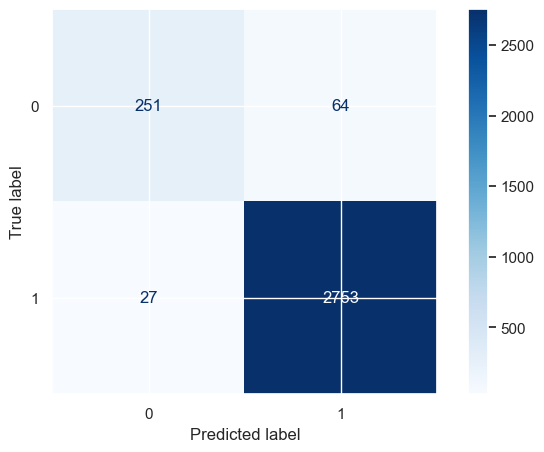

In [90]:
# Gráfico no normalizado de la martiz de confusión

disp = plot_confusion_matrix(modelo_final, X_test, y_test,
                                 cmap=plt.cm.Blues, values_format = '')
sns.set(rc={'figure.figsize':(5,5)})

Ahora la curva ROC/AUC

Mietras la curva ROC nos da la tasa de verdaderos positivos frente la tasa de falsos positivos, el área bajo la curva (AUC) ROC es la probabilidad de que un clasificador tenga más confianza en que un ejemplo positivo aleatorio es realmente poistivo en relación a un negativo aleatorio también

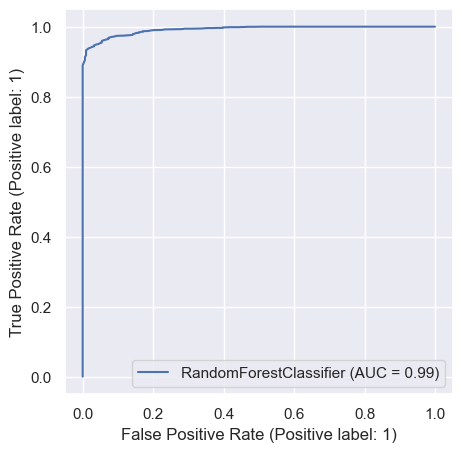

In [91]:
from sklearn.metrics import roc_auc_score, plot_roc_curve, roc_curve, auc

plot_roc_curve(modelo_final, X_test, y_test)
auc = roc_auc_score(y_test, y_predict)

# Conclusiones

Vemos que el resultado obtenido por la curva es casi perfecto, estamos hablando del 99% por lo que el modelo obtenido es muy satisfactorio